# 11. Make Preliminary Figures

Goal:
- Collect the main preliminary results into clean figures.
- Focus on:
  1. Behavior model comparison
  2. Trial-level uncertainty calibration
  3. DMFC residual alignment beyond y_det
  4. Event-aligned time-resolved residual contribution

Important:
- These are preliminary figures for discussion, not final figures.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR = RESULTS_DIR / "preliminary_figures"

FIG_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("FIG_DIR:", FIG_DIR)

PROJECT_ROOT: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents
PROCESSED_DIR: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed
FIG_DIR: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\results\preliminary_figures


In [3]:
trial_cal_summary_path = PROCESSED_DIR / "trial_level_calibrated_behavior_summary_mahler.csv"

if trial_cal_summary_path.exists():
    trial_cal_summary = pd.read_csv(trial_cal_summary_path)
else:
    print("trial calibrated summary file not found. Creating from pasted results manually.")
    
    trial_cal_summary = pd.DataFrame([
        {
            "model": "M6_calibrated_sigma",
            "mean_nll": 2.233951,
            "sem_nll": 0.017834,
            "mean_mae": 1.636706,
            "mean_rmse": 2.354823,
            "mean_sigma_test": 2.340110,
            "mean_lambda": 0.86,
            "mean_sigma0": 1.931313,
        },
        {
            "model": "M1_mean_M6_calibrated_sigma",
            "mean_nll": 2.234101,
            "sem_nll": 0.018228,
            "mean_mae": 1.636214,
            "mean_rmse": 2.353418,
            "mean_sigma_test": 2.340110,
            "mean_lambda": 0.86,
            "mean_sigma0": 1.931313,
        },
        {
            "model": "M1_const_sigma",
            "mean_nll": 2.279511,
            "sem_nll": 0.033072,
            "mean_mae": 1.636214,
            "mean_rmse": 2.353418,
            "mean_sigma_test": 2.361147,
            "mean_lambda": np.nan,
            "mean_sigma0": 2.361147,
        },
        {
            "model": "M6_mean_const_sigma",
            "mean_nll": 2.280070,
            "sem_nll": 0.032885,
            "mean_mae": 1.636706,
            "mean_rmse": 2.354823,
            "mean_sigma_test": 2.362458,
            "mean_lambda": np.nan,
            "mean_sigma0": 2.362458,
        },
        {
            "model": "M6_raw_sigma",
            "mean_nll": 4.626791,
            "sem_nll": 0.875125,
            "mean_mae": 1.636706,
            "mean_rmse": 2.354823,
            "mean_sigma_test": 1.248604,
            "mean_lambda": np.nan,
            "mean_sigma0": np.nan,
        },
    ])
    
    trial_cal_summary.to_csv(trial_cal_summary_path, index=False)
    print("Saved manual summary:", trial_cal_summary_path)

display(trial_cal_summary)

trial calibrated summary file not found. Creating from pasted results manually.
Saved manual summary: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\trial_level_calibrated_behavior_summary_mahler.csv


,model,mean_nll,sem_nll,mean_mae,mean_rmse,mean_sigma_test,mean_lambda,mean_sigma0
0,M6_calibrated_sigma,2.233951,0.017834,1.636706,2.354823,2.340110,0.86,1.931313
1,M1_mean_M6_calibrated_sigma,2.234101,0.018228,1.636214,2.353418,2.340110,0.86,1.931313
2,M1_const_sigma,2.279511,0.033072,1.636214,2.353418,2.361147,NaN,2.361147
3,M6_mean_const_sigma,2.280070,0.032885,1.636706,2.354823,2.362458,NaN,2.362458
4,M6_raw_sigma,4.626791,0.875125,1.636706,2.354823,1.248604,NaN,NaN


In [4]:
paths = {
    # behavior
    "behavior_summary": PROCESSED_DIR / "final_behavior_model_summary_mahler.csv",
    "trial_cal_summary": PROCESSED_DIR / "trial_level_calibrated_behavior_summary_mahler.csv",
    
    # neural residual window/shuffle
    "residual_shuffle_summary": PROCESSED_DIR / "dmfc_paddle_residual_shuffle_summary_mahler.csv",
    "residual_observed": PROCESSED_DIR / "dmfc_paddle_residual_observed_mahler.csv",
    
    # time/event aligned
    "event_delta": PROCESSED_DIR / "dmfc_event_aligned_delta_r2_mahler.csv",
    "event_shuffle_summary": PROCESSED_DIR / "dmfc_event_aligned_residual_shuffle_summary_mahler.csv",
    "event_cluster": PROCESSED_DIR / "dmfc_event_aligned_residual_cluster_summary_mahler.csv",
    
    # optional
    "time_delta": PROCESSED_DIR / "dmfc_time_resolved_delta_r2_mahler.csv",
    "time_shuffle_summary": PROCESSED_DIR / "dmfc_time_resolved_residual_shuffle_summary_mahler.csv",
    "time_cluster": PROCESSED_DIR / "dmfc_time_resolved_residual_cluster_summary_mahler.csv",
}

for name, path in paths.items():
    print(f"{name:25s}", path.exists(), path)

behavior_summary          True c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\final_behavior_model_summary_mahler.csv
trial_cal_summary         True c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\trial_level_calibrated_behavior_summary_mahler.csv
residual_shuffle_summary  True c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_paddle_residual_shuffle_summary_mahler.csv
residual_observed         True c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_paddle_residual_observed_mahler.csv
event_delta               True c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_event_aligned_delta_r2_mahler.csv
event_shuffle_summary     True c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_event_aligned_residual_shuffle_summary_mahler.csv
event_cluster             True c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\data\processed\dmfc_event_aligned_residual_cluster_summary_mahler.csv

In [5]:
# helper func
def savefig(name):
    path_png = FIG_DIR / f"{name}.png"
    path_pdf = FIG_DIR / f"{name}.pdf"
    plt.savefig(path_png, dpi=200, bbox_inches="tight")
    plt.savefig(path_pdf, bbox_inches="tight")
    print("Saved:", path_png)
    print("Saved:", path_pdf)


def clean_model_name(name):
    mapping = {
        "M1_biased_deterministic": "M1 biased det.",
        "M4_biased_mc_ipe": "M4 MC-IPE",
        "M4_uncertainty_only": "M4 uncertainty-only",
        "M5_heteroscedastic_deterministic": "M5 task uncertainty",
        "M6_mc_mean_task_uncertainty": "M6 MC mean + task σ",
        "M1_const_sigma": "M1 const σ",
        "M6_raw_sigma": "M6 raw σ",
        "M6_mean_const_sigma": "M6 mean + const σ",
        "M6_calibrated_sigma": "M6 calibrated σ",
        "M1_mean_M6_calibrated_sigma": "M1 mean + M6 calibrated σ",
    }
    return mapping.get(name, name)


def add_value_labels(ax, values, fmt="{:.3f}", y_offset=0.01):
    ymin, ymax = ax.get_ylim()
    yrange = ymax - ymin
    
    for i, v in enumerate(values):
        if np.isfinite(v):
            ax.text(
                i,
                v + y_offset * yrange,
                fmt.format(v),
                ha="center",
                va="bottom",
                fontsize=9,
            )

## Figure 1. Conditional-level behavior model comparison

Conditional-level behavior was best explained by a model combining MC-derived mean with task-difficulty-based uncertainty, or by the task-difficulty heteroscedastic baseline depending on saved summary. The key point is that uncertainty must be condition-dependent rather than constant.

In [6]:
behavior_summary = pd.read_csv(paths["behavior_summary"])

display(behavior_summary)

# 필요한 모델만 선택
preferred_order = [
    "M1_biased_deterministic",
    "M4_uncertainty_only",
    "M4_biased_mc_ipe",
    "M5_heteroscedastic_deterministic",
    "M6_mc_mean_task_uncertainty",
]

behavior_plot = behavior_summary[
    behavior_summary["model"].isin(preferred_order)
].copy()

behavior_plot["model_clean"] = behavior_plot["model"].apply(clean_model_name)
behavior_plot["order"] = behavior_plot["model"].apply(lambda x: preferred_order.index(x) if x in preferred_order else 999)
behavior_plot = behavior_plot.sort_values("order")

display(behavior_plot)

,model,mean_nll,sem_nll,mean_mae,mean_rmse,mean_corr
0,M6_mc_mean_task_uncertainty,1.505535,0.075586,0.842501,1.204301,0.964880
1,M5_heteroscedastic_deterministic,1.584212,0.059826,0.883269,1.242161,0.964047
2,M4_biased_mc_ipe,1.629098,0.053820,0.822282,1.211059,0.963920
3,M4_uncertainty_only,1.654691,0.050209,0.883269,1.242161,0.964047
4,M1_biased_deterministic,1.758013,0.215236,0.883269,1.242161,0.964047


,model,mean_nll,sem_nll,mean_mae,mean_rmse,mean_corr,model_clean,order
4,M1_biased_deterministic,1.758013,0.215236,0.883269,1.242161,0.964047,M1 biased det.,0
3,M4_uncertainty_only,1.654691,0.050209,0.883269,1.242161,0.964047,M4 uncertainty-only,1
2,M4_biased_mc_ipe,1.629098,0.053820,0.822282,1.211059,0.963920,M4 MC-IPE,2
1,M5_heteroscedastic_deterministic,1.584212,0.059826,0.883269,1.242161,0.964047,M5 task uncertainty,3
0,M6_mc_mean_task_uncertainty,1.505535,0.075586,0.842501,1.204301,0.964880,M6 MC mean + task σ,4


Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\results\preliminary_figures\fig1_condition_level_behavior_model_comparison.png
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\results\preliminary_figures\fig1_condition_level_behavior_model_comparison.pdf


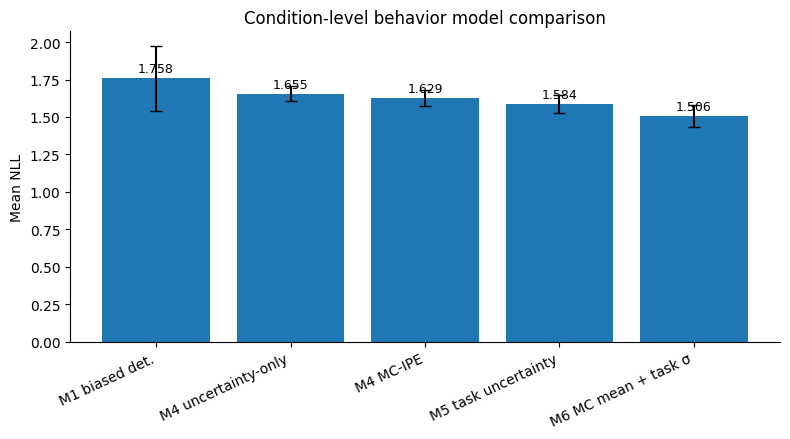

In [7]:
# fig 1 plot

fig, ax = plt.subplots(figsize=(8, 4.5))

x = np.arange(len(behavior_plot))
y = behavior_plot["mean_nll"].values
err = behavior_plot["sem_nll"].values if "sem_nll" in behavior_plot.columns else None

ax.bar(x, y, yerr=err, capsize=4)

ax.set_xticks(x)
ax.set_xticklabels(behavior_plot["model_clean"], rotation=25, ha="right")
ax.set_ylabel("Mean NLL")
ax.set_title("Condition-level behavior model comparison")

add_value_labels(ax, y)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
savefig("fig1_condition_level_behavior_model_comparison")
plt.show()

## Figure 2. Trial-level calibrated behavior model comparison

Raw M6 uncertainty was overconfident at the trial level. After adding a response-noise floor, M6-derived uncertainty structure improved trial-level likelihood over a constant-sigma baseline.

In [8]:
trial_cal_summary = pd.read_csv(paths["trial_cal_summary"])

display(trial_cal_summary)

trial_order = [
    "M6_raw_sigma",
    "M1_const_sigma",
    "M6_mean_const_sigma",
    "M1_mean_M6_calibrated_sigma",
    "M6_calibrated_sigma",
]

trial_plot = trial_cal_summary[
    trial_cal_summary["model"].isin(trial_order)
].copy()

trial_plot["model_clean"] = trial_plot["model"].apply(clean_model_name)
trial_plot["order"] = trial_plot["model"].apply(lambda x: trial_order.index(x) if x in trial_order else 999)
trial_plot = trial_plot.sort_values("order")

display(trial_plot)

,model,mean_nll,sem_nll,mean_mae,mean_rmse,mean_sigma_test,mean_lambda,mean_sigma0
0,M6_calibrated_sigma,2.233951,0.017834,1.636706,2.354823,2.340110,0.86,1.931313
1,M1_mean_M6_calibrated_sigma,2.234101,0.018228,1.636214,2.353418,2.340110,0.86,1.931313
2,M1_const_sigma,2.279511,0.033072,1.636214,2.353418,2.361147,NaN,2.361147
3,M6_mean_const_sigma,2.280070,0.032885,1.636706,2.354823,2.362458,NaN,2.362458
4,M6_raw_sigma,4.626791,0.875125,1.636706,2.354823,1.248604,NaN,NaN


,model,mean_nll,sem_nll,mean_mae,mean_rmse,mean_sigma_test,mean_lambda,mean_sigma0,model_clean,order
4,M6_raw_sigma,4.626791,0.875125,1.636706,2.354823,1.248604,NaN,NaN,M6 raw σ,0
2,M1_const_sigma,2.279511,0.033072,1.636214,2.353418,2.361147,NaN,2.361147,M1 const σ,1
3,M6_mean_const_sigma,2.280070,0.032885,1.636706,2.354823,2.362458,NaN,2.362458,M6 mean + const σ,2
1,M1_mean_M6_calibrated_sigma,2.234101,0.018228,1.636214,2.353418,2.340110,0.86,1.931313,M1 mean + M6 calibrated σ,3
0,M6_calibrated_sigma,2.233951,0.017834,1.636706,2.354823,2.340110,0.86,1.931313,M6 calibrated σ,4


Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\results\preliminary_figures\fig2_trial_level_uncertainty_calibration.png
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\results\preliminary_figures\fig2_trial_level_uncertainty_calibration.pdf


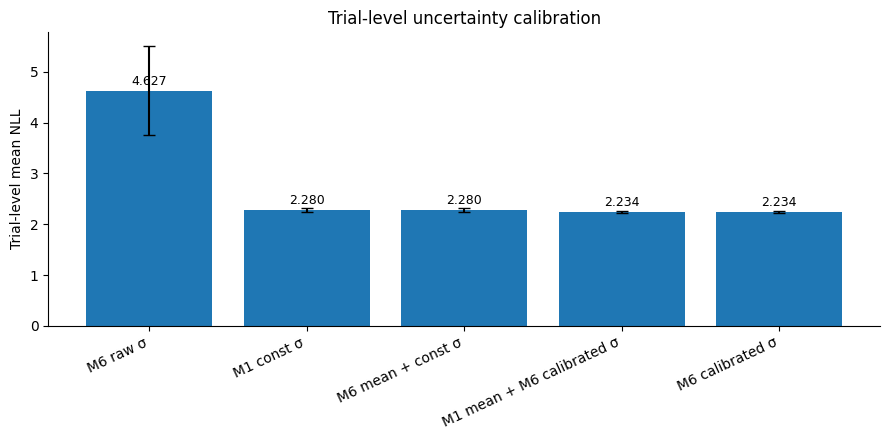

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))

x = np.arange(len(trial_plot))
y = trial_plot["mean_nll"].values
err = trial_plot["sem_nll"].values if "sem_nll" in trial_plot.columns else None

ax.bar(x, y, yerr=err, capsize=4)

ax.set_xticks(x)
ax.set_xticklabels(trial_plot["model_clean"], rotation=25, ha="right")
ax.set_ylabel("Trial-level mean NLL")
ax.set_title("Trial-level uncertainty calibration")

add_value_labels(ax, y)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
savefig("fig2_trial_level_uncertainty_calibration")
plt.show()

,model,mean_sigma_test,mean_lambda,mean_sigma0,mean_nll
0,M6_calibrated_sigma,2.34011,0.86,1.931313,2.233951
1,M1_mean_M6_calibrated_sigma,2.34011,0.86,1.931313,2.234101


Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\results\preliminary_figures\fig2b_trial_level_calibration_parameters.png
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\results\preliminary_figures\fig2b_trial_level_calibration_parameters.pdf


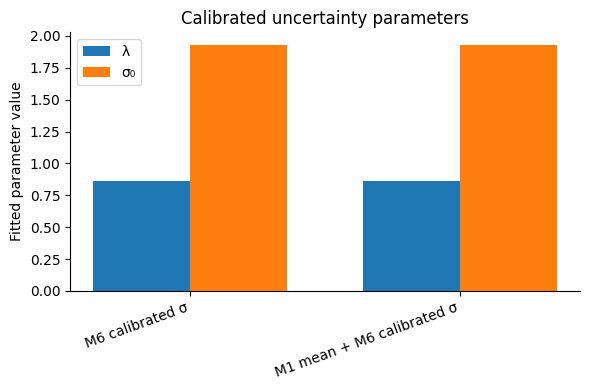

In [10]:
# fig 2b: sigma calibration parameters
calibrated = trial_cal_summary[
    trial_cal_summary["model"].isin([
        "M6_calibrated_sigma",
        "M1_mean_M6_calibrated_sigma",
    ])
].copy()

display(calibrated[[
    "model",
    "mean_sigma_test",
    "mean_lambda",
    "mean_sigma0",
    "mean_nll",
]])

fig, ax = plt.subplots(figsize=(6, 4))

labels = calibrated["model"].apply(clean_model_name).values
x = np.arange(len(calibrated))

ax.bar(x - 0.18, calibrated["mean_lambda"].values, width=0.36, label="λ")
ax.bar(x + 0.18, calibrated["mean_sigma0"].values, width=0.36, label="σ₀")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Fitted parameter value")
ax.set_title("Calibrated uncertainty parameters")
ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
savefig("fig2b_trial_level_calibration_parameters")
plt.show()

## Figure 3. DMFC residual encoding / shuffle control

$y_{\text{det}} + \text{paddle residual}$ 이 $y_{\text{det}}$ 보다 좋아지고, shuffle distribution 보다 훨씬 큼.

In [11]:
residual_shuffle_summary = pd.read_csv(paths["residual_shuffle_summary"])

display(residual_shuffle_summary)

# expected columns:
# window, base_r2, observed_r2, observed_delta_r2,
# shuffle_mean_delta, shuffle_std_delta, shuffle_p95, shuffle_p99, empirical_p

window_order = ["pre_occ", "early_occ", "late_occ", "full_occ"]

residual_shuffle_summary["window_order"] = residual_shuffle_summary["window"].apply(
    lambda x: window_order.index(x) if x in window_order else 999
)

residual_plot = residual_shuffle_summary.sort_values("window_order").copy()

display(residual_plot)

,window,base_r2,observed_r2,observed_delta_r2,shuffle_mean_delta,shuffle_std_delta,shuffle_p95,shuffle_p99,empirical_p
0,pre_occ,0.458412,0.484489,0.026078,-0.008774,0.005189,-0.000572,0.002383,0.004975
1,early_occ,0.442656,0.463417,0.020761,-0.008937,0.005035,-0.000884,0.001955,0.004975
2,late_occ,0.424147,0.446009,0.021862,-0.009375,0.005474,-0.000557,0.003534,0.004975
3,full_occ,0.448578,0.477865,0.029287,-0.009119,0.005020,-0.001038,0.002560,0.004975


,window,base_r2,observed_r2,observed_delta_r2,shuffle_mean_delta,shuffle_std_delta,shuffle_p95,shuffle_p99,empirical_p,window_order
0,pre_occ,0.458412,0.484489,0.026078,-0.008774,0.005189,-0.000572,0.002383,0.004975,0
1,early_occ,0.442656,0.463417,0.020761,-0.008937,0.005035,-0.000884,0.001955,0.004975,1
2,late_occ,0.424147,0.446009,0.021862,-0.009375,0.005474,-0.000557,0.003534,0.004975,2
3,full_occ,0.448578,0.477865,0.029287,-0.009119,0.005020,-0.001038,0.002560,0.004975,3


Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\results\preliminary_figures\fig3_dmfc_residual_shuffle_control.png
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\results\preliminary_figures\fig3_dmfc_residual_shuffle_control.pdf


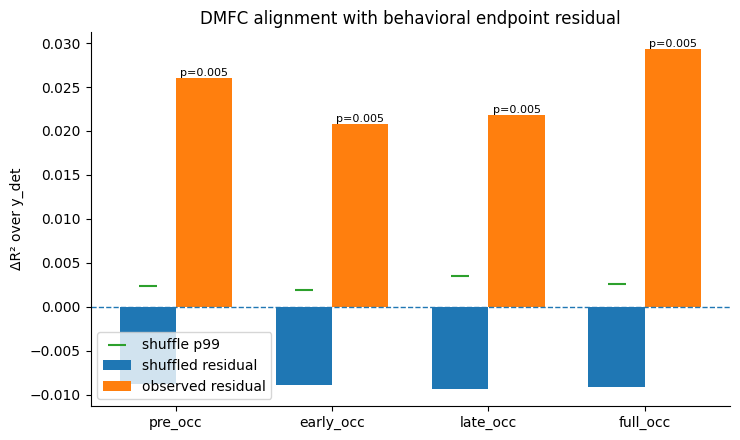

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))

x = np.arange(len(residual_plot))

ax.bar(
    x - 0.18,
    residual_plot["shuffle_mean_delta"].values,
    width=0.36,
    label="shuffled residual",
)

ax.bar(
    x + 0.18,
    residual_plot["observed_delta_r2"].values,
    width=0.36,
    label="observed residual",
)

# p99 marker
ax.scatter(
    x - 0.18,
    residual_plot["shuffle_p99"].values,
    marker="_",
    s=180,
    label="shuffle p99",
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(residual_plot["window"])
ax.set_ylabel("ΔR² over y_det")
ax.set_title("DMFC alignment with behavioral endpoint residual")
ax.legend()

for i, row in enumerate(residual_plot.itertuples()):
    ax.text(
        i + 0.18,
        row.observed_delta_r2,
        f"p={row.empirical_p:.3f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
savefig("fig3_dmfc_residual_shuffle_control")
plt.show()

## Figure 4. Event-aligned residual $\Delta R^2$ cluster result

residual $\Delta R^2$ 가 occ-aligned와 final-aligned 양쪽에서 cluster-level로 나타남. 특히 occ 이후 / final 이전 구간이 중요.

In [13]:
event_shuffle_summary = pd.read_csv(paths["event_shuffle_summary"])
event_cluster = pd.read_csv(paths["event_cluster"])

display(event_shuffle_summary.head())
display(event_cluster)

# significant clusters
sig_clusters = event_cluster[event_cluster["cluster_p"] < 0.05].copy()
display(sig_clusters)

,align_name,rel_time,observed_delta_r2,shuffle_mean_delta,shuffle_std_delta,shuffle_p95,shuffle_p99,empirical_p
0,final,-50,0.002134,-0.007720,0.022011,0.015158,0.028563,0.277228
1,final,-49,-0.000532,-0.012538,0.022532,0.018107,0.032881,0.306931
2,final,-48,-0.040432,-0.010041,0.031177,0.026930,0.047530,0.920792
3,final,-47,0.004762,-0.014010,0.021757,0.015792,0.030532,0.158416
4,final,-46,0.027026,-0.006235,0.023904,0.016726,0.037221,0.029703


,align_name,cluster_start_rel,cluster_end_rel,cluster_len,cluster_mass,threshold,cluster_p
0,final,-12,-7,6,0.118340,0.010733,0.009901
1,final,33,36,4,0.107410,0.010733,0.009901
2,final,19,22,4,0.098171,0.010733,0.009901
3,final,-26,-22,5,0.089230,0.010733,0.009901
4,final,24,28,5,0.088687,0.010733,0.009901
5,final,3,4,2,0.061598,0.010733,0.029703
6,final,14,15,2,0.052539,0.010733,0.059406
7,final,-40,-38,3,0.043480,0.010733,0.069307
8,final,-17,-16,2,0.037582,0.010733,0.089109
9,final,0,1,2,0.035201,0.010733,0.108911


,align_name,cluster_start_rel,cluster_end_rel,cluster_len,cluster_mass,threshold,cluster_p
0,final,-12,-7,6,0.118340,0.010733,0.009901
1,final,33,36,4,0.107410,0.010733,0.009901
2,final,19,22,4,0.098171,0.010733,0.009901
3,final,-26,-22,5,0.089230,0.010733,0.009901
4,final,24,28,5,0.088687,0.010733,0.009901
5,final,3,4,2,0.061598,0.010733,0.029703
23,occ,40,41,2,0.117648,0.009911,0.009901
24,occ,20,25,6,0.108141,0.009911,0.009901
25,occ,1,2,2,0.063703,0.009911,0.009901
26,occ,10,12,3,0.060420,0.009911,0.009901


In [14]:
def plot_event_aligned_delta(align_name, filename):
    sub = event_shuffle_summary[
        event_shuffle_summary["align_name"] == align_name
    ].sort_values("rel_time").copy()
    
    clusters = sig_clusters[
        sig_clusters["align_name"] == align_name
    ].copy()
    
    fig, ax = plt.subplots(figsize=(10, 4.5))
    
    ax.plot(
        sub["rel_time"],
        sub["observed_delta_r2"],
        linewidth=2,
        label="observed ΔR²",
    )
    
    ax.plot(
        sub["rel_time"],
        sub["shuffle_mean_delta"],
        linewidth=1,
        label="shuffle mean",
    )
    
    ax.fill_between(
        sub["rel_time"],
        sub["shuffle_p95"],
        sub["shuffle_p99"],
        alpha=0.25,
        label="shuffle p95-p99",
    )
    
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.axvline(0, linestyle="--", linewidth=1.2, label=f"{align_name} event")
    
    for _, row in clusters.iterrows():
        ax.axvspan(
            row["cluster_start_rel"],
            row["cluster_end_rel"],
            alpha=0.18,
        )
    
    ax.set_xlabel(f"Time relative to {align_name} event (50 ms bins)")
    ax.set_ylabel("ΔR² over y_det")
    ax.set_title(f"{align_name}-aligned residual contribution")
    ax.legend()
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    plt.tight_layout()
    savefig(filename)
    plt.show()

Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\results\preliminary_figures\fig4a_occ_aligned_residual_delta_r2.png
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\results\preliminary_figures\fig4a_occ_aligned_residual_delta_r2.pdf


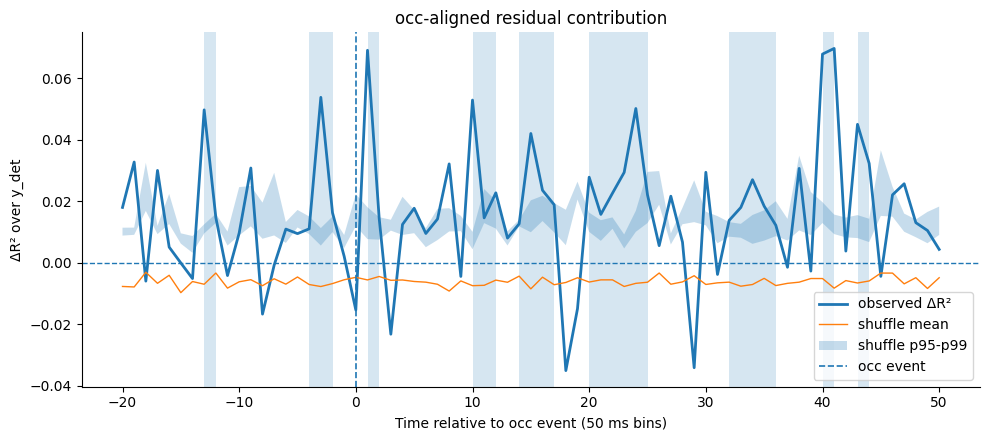

Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\results\preliminary_figures\fig4b_final_aligned_residual_delta_r2.png
Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\results\preliminary_figures\fig4b_final_aligned_residual_delta_r2.pdf


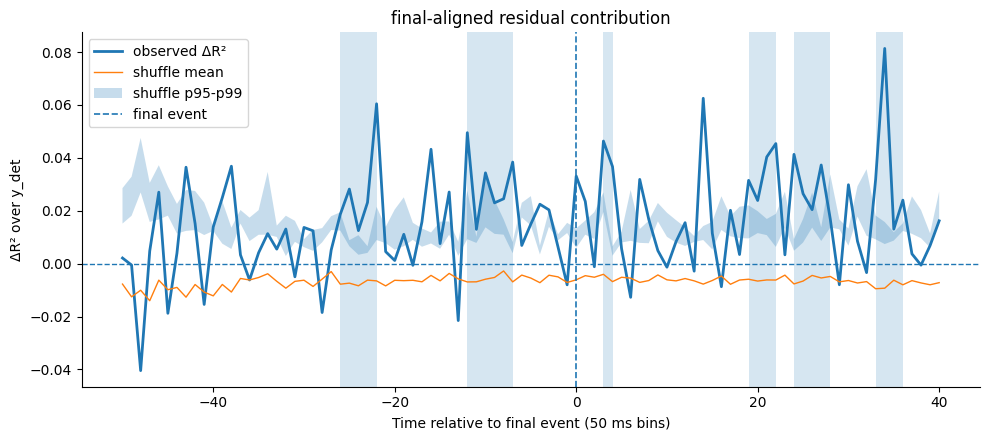

In [15]:
plot_event_aligned_delta(
    align_name="occ",
    filename="fig4a_occ_aligned_residual_delta_r2",
)

plot_event_aligned_delta(
    align_name="final",
    filename="fig4b_final_aligned_residual_delta_r2",
)

## Figure 5 optional. Summary schematic-style table

In [16]:
summary_rows = [
    {
        "Analysis block": "Condition-level behavior",
        "Main result": "Condition-dependent uncertainty improves behavior likelihood",
        "Conservative interpretation": "Mean response and uncertainty are not fully captured by deterministic target alone",
    },
    {
        "Analysis block": "Trial-level behavior",
        "Main result": "Raw M6 is overconfident; calibrated M6 improves NLL",
        "Conservative interpretation": "Model-derived uncertainty captures condition-wise variability structure but requires response-noise floor",
    },
    {
        "Analysis block": "Window-level DMFC encoding",
        "Main result": "Paddle residual improves R² beyond y_det and beats shuffle",
        "Conservative interpretation": "DMFC activity is aligned with behavioral endpoint structure beyond deterministic target",
    },
    {
        "Analysis block": "Event-aligned DMFC encoding",
        "Main result": "Residual ΔR² forms significant clusters around occ/final aligned time",
        "Conservative interpretation": "Residual-related structure is not only a static averaging artifact",
    },
]

summary_table = pd.DataFrame(summary_rows)
display(summary_table)

summary_table_path = FIG_DIR / "preliminary_result_summary_table.csv"
summary_table.to_csv(summary_table_path, index=False)
print("Saved:", summary_table_path)

,Analysis block,Main result,Conservative interpretation
0,Condition-level behavior,Condition-dependent uncertainty improves behav...,Mean response and uncertainty are not fully ca...
1,Trial-level behavior,Raw M6 is overconfident; calibrated M6 improve...,Model-derived uncertainty captures condition-w...
2,Window-level DMFC encoding,Paddle residual improves R² beyond y_det and b...,DMFC activity is aligned with behavioral endpo...
3,Event-aligned DMFC encoding,Residual ΔR² forms significant clusters around...,Residual-related structure is not only a stati...


Saved: c:\Users\ksbong\Documents\GitHub\ipe-pong-latents\results\preliminary_figures\preliminary_result_summary_table.csv


In [17]:
fig_files = sorted(FIG_DIR.glob("*"))

for p in fig_files:
    print(p.name)

fig1_condition_level_behavior_model_comparison.pdf
fig1_condition_level_behavior_model_comparison.png
fig2_trial_level_uncertainty_calibration.pdf
fig2_trial_level_uncertainty_calibration.png
fig2b_trial_level_calibration_parameters.pdf
fig2b_trial_level_calibration_parameters.png
fig3_dmfc_residual_shuffle_control.pdf
fig3_dmfc_residual_shuffle_control.png
fig4a_occ_aligned_residual_delta_r2.pdf
fig4a_occ_aligned_residual_delta_r2.png
fig4b_final_aligned_residual_delta_r2.pdf
fig4b_final_aligned_residual_delta_r2.png
preliminary_result_summary_table.csv
